In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

/Users/jaspreetkaur/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/8w/70d9nj0n3fg4mz1rrt0dd2780000gn/T/matplotlib-q8blo6e6 because there was an issue with the default path (/Users/jaspreetkaur/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


In [2]:
df=pd.read_csv('Churn_Modelling.csv')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [3]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<Axes: xlabel='Age', ylabel='Density'>

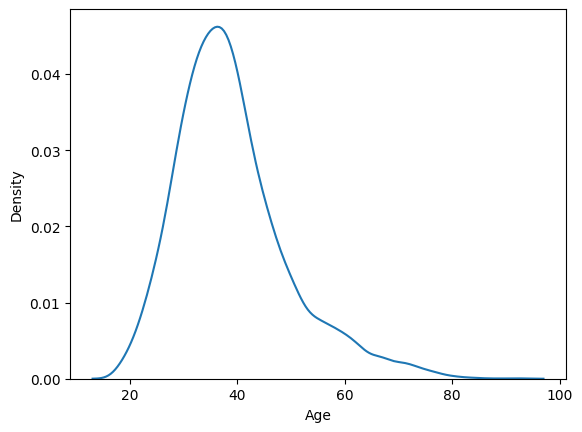

In [7]:
sns.kdeplot(df['Age'])

<Axes: xlabel='Balance', ylabel='Density'>

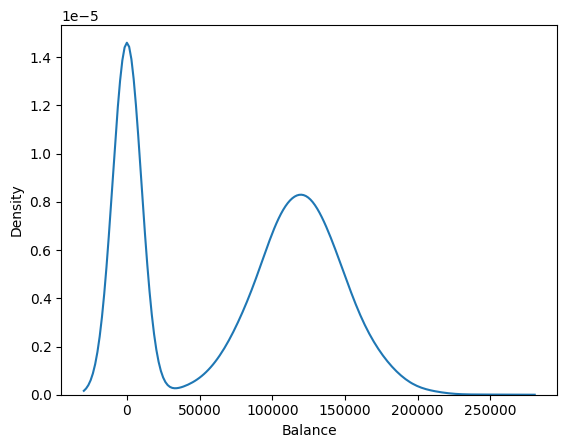

In [8]:
sns.kdeplot(df['Balance'])

<Axes: xlabel='Age', ylabel='Balance'>

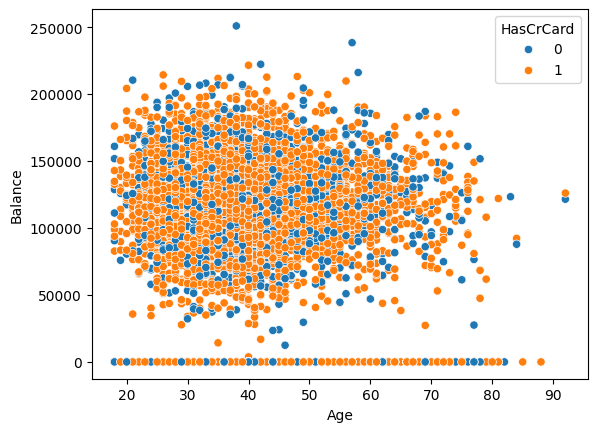

In [14]:
color_dict={1:'gre', 2:'green', 3:'blue'}
sns.scatterplot(
    data=df,
    x=df['Age'],
    y=df['Balance'],
    hue=df['HasCrCard']
)

In [15]:
X=df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
y= df['Exited']

In [16]:
X.sample(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
2510,625,France,Female,52,2,79468.96,1,1,1,84606.03
4165,775,France,Male,60,7,0.00,2,1,1,111558.70
226,694,France,Female,30,9,0.00,2,1,1,26960.31
3190,585,France,Female,28,6,105795.90,1,1,1,41219.09
6885,698,France,Female,27,1,94920.71,1,1,1,40339.90


Need data in numeric form so use OneHot Encoding for Geography and Gender

In [18]:
X=df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
y= df['Exited']

In [19]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
5284,5285,15759250,Barnett,745,Germany,Male,51,3,99183.90,1,1,1,28922.25,0
4561,4562,15638028,Ifeanyichukwu,562,Germany,Male,31,4,127237.25,2,0,1,143317.42,0
4210,4211,15731117,Kao,437,Spain,Male,28,2,109161.25,1,1,0,152987.42,0
3122,3123,15575002,Ferguson,676,France,Male,29,4,140720.93,1,1,0,36221.18,0
9099,9100,15768881,Saunders,738,France,Male,29,2,0.00,2,1,1,170421.13,0


In [20]:
X = pd.get_dummies(X, drop_first=True)

In [22]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Geography_Germany  10000 non-null  bool   
 9   Geography_Spain    10000 non-null  bool   
 10  Gender_Male        10000 non-null  bool   
dtypes: bool(3), float64(2), int64(6)
memory usage: 654.4 KB


In [23]:
X.sample(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
6686,621,50,3,163085.79,1,0,1,131048.36,False,True,True
3650,537,38,3,0.00,2,0,0,141023.01,False,False,True
6261,708,35,8,122570.69,1,0,0,199005.88,False,True,False
633,540,44,3,164113.04,2,1,1,12120.79,True,False,True
8353,524,32,6,0.00,1,1,1,132861.90,False,True,False


Split data

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
X_train.shape, X_test.shape

((8000, 11), (2000, 11))

In [26]:
y_test.shape, y_train.shape

((2000,), (8000,))

In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler= MinMaxScaler()

# fit the scaler to train data
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [29]:
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [30]:
np.round(X_train.describe(), 1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,8000.0,8000.0,8000.0,8000.0,8000.0,8000.0,8000.0,8000.0
mean,651.6,38.9,5.0,76102.1,1.5,0.7,0.5,100431.3
std,96.4,10.5,2.9,62461.0,0.6,0.5,0.5,57518.9
min,350.0,18.0,0.0,0.0,1.0,0.0,0.0,90.1
25%,585.0,32.0,3.0,0.0,1.0,0.0,0.0,51364.1
50%,653.0,37.0,5.0,96447.5,1.0,1.0,1.0,100487.7
75%,719.0,44.0,7.0,127611.3,2.0,1.0,1.0,149595.8
max,850.0,92.0,10.0,250898.1,4.0,1.0,1.0,199970.7


In [31]:
np.round(X_train_scaled.describe(),1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
count,8000.0,8000.0,8000.0,8000.0,8000.0,8000.0,8000.0,8000.0,8000.0,8000.0,8000.0
mean,0.6,0.3,0.5,0.3,0.2,0.7,0.5,0.5,0.3,0.2,0.5
std,0.2,0.1,0.3,0.2,0.2,0.5,0.5,0.3,0.4,0.4,0.5
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.5,0.2,0.3,0.0,0.0,0.0,0.0,0.3,0.0,0.0,0.0
50%,0.6,0.3,0.5,0.4,0.0,1.0,1.0,0.5,0.0,0.0,1.0
75%,0.7,0.4,0.7,0.5,0.3,1.0,1.0,0.7,1.0,0.0,1.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


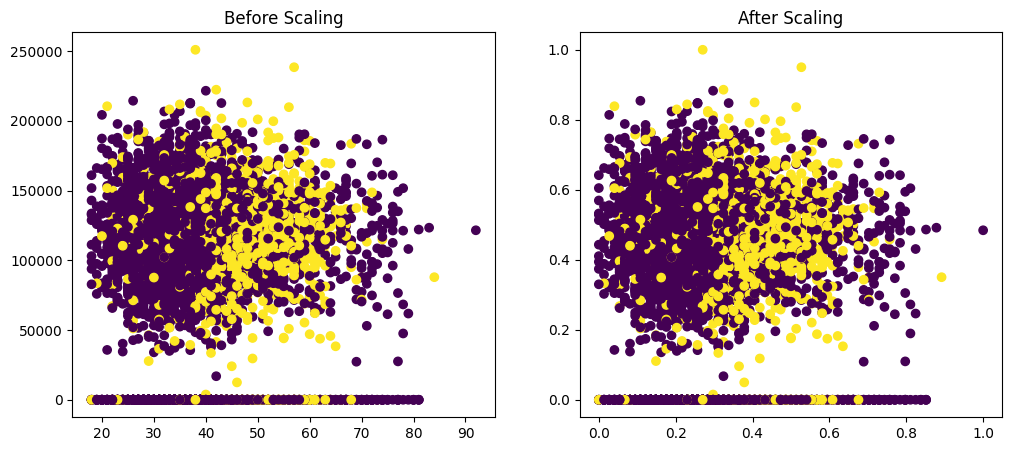

In [32]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['Balance'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['Balance'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

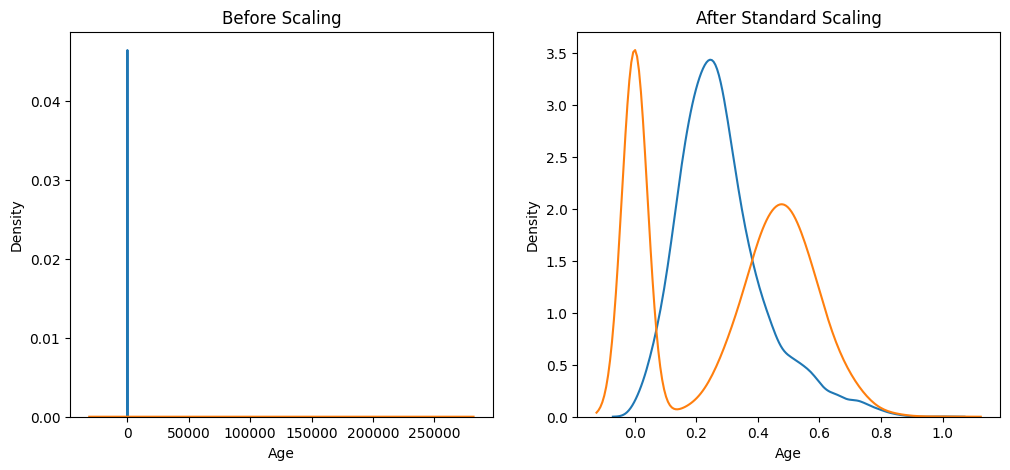

In [33]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['Balance'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['Balance'], ax=ax2)
plt.show()

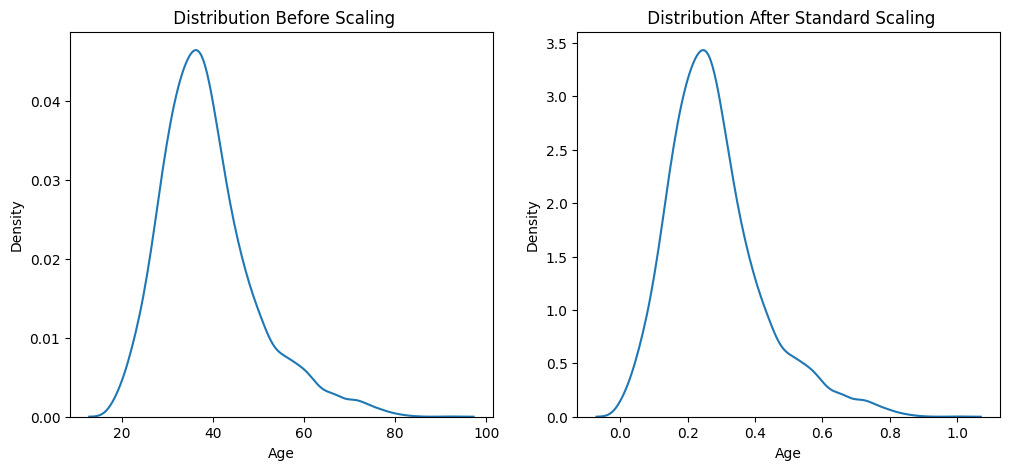

In [34]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title(' Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling
ax2.set_title(' Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
plt.show()

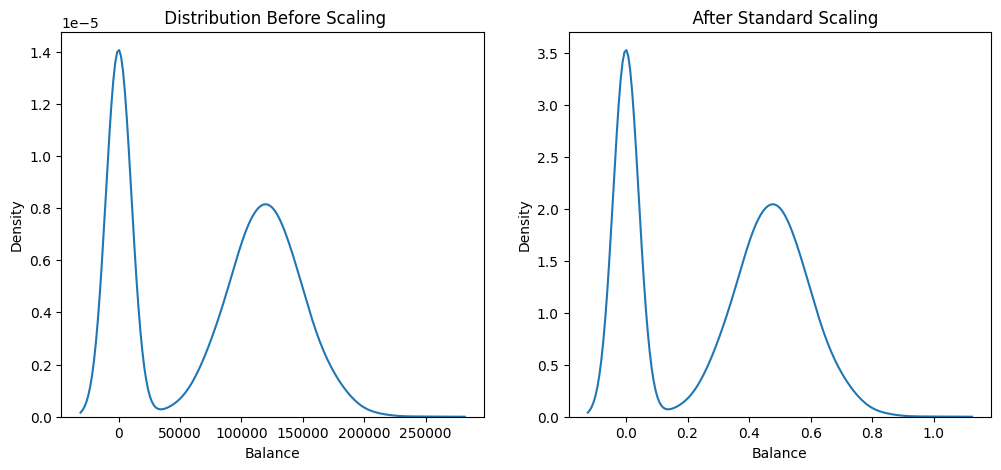

In [35]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title(' Distribution Before Scaling')
sns.kdeplot(X_train['Balance'], ax=ax1)

# after scaling
ax2.set_title('  After Standard Scaling')
sns.kdeplot(X_train_scaled['Balance'], ax=ax2)
plt.show()

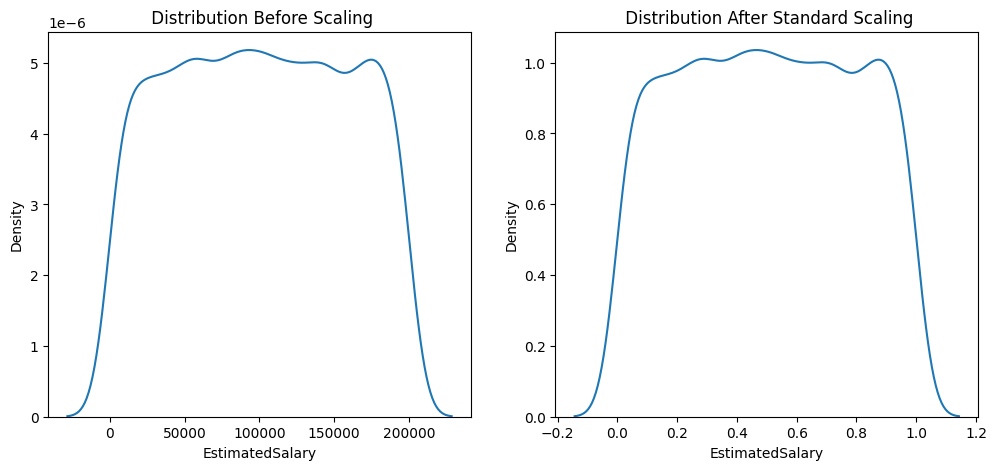

In [36]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title(' Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title(' Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

<Axes: xlabel='Balance', ylabel='Count'>

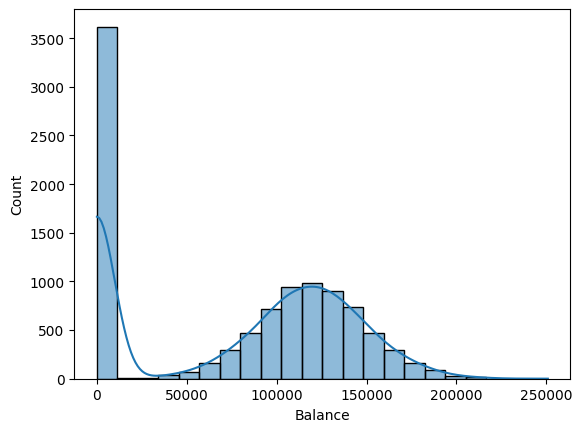

In [37]:
sns.histplot(df['Balance'], kde=True)

<Axes: >

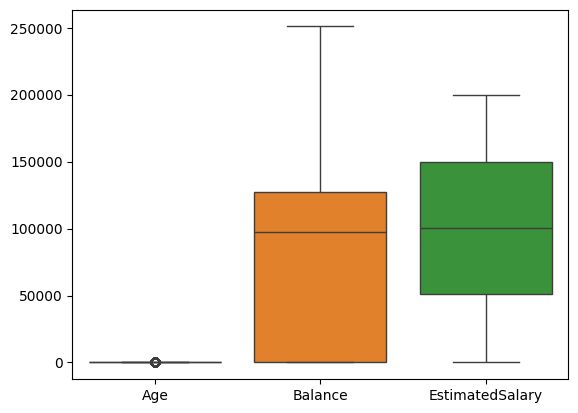

In [41]:
sns.boxplot(data=df[['Age','Balance','EstimatedSalary']])

<Axes: >

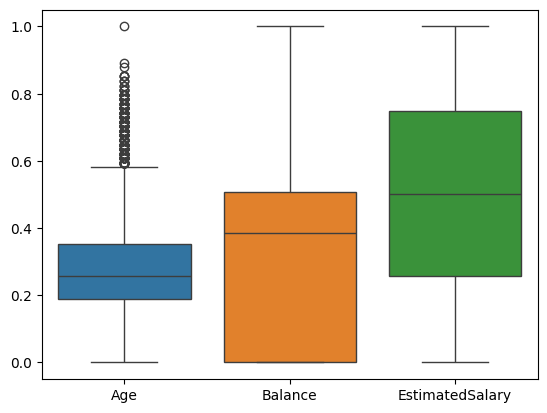

In [42]:
scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
sns.boxplot(data=scaled_df[['Age','Balance','EstimatedSalary']])